# Long-term reflection length

Data:
- `long_term_reflection_analysis_data/long_term_reflection_analysis_oragent_tsp_pomo_output.txt`: `algorithm=oragent`, `problem=tsp_pomo`, stdout

In [13]:
def extract_long_term_reflections(output_content: str):
    """Extract the long-term reflections from the output_content.

    Args:
        output_content (str): the output content

    Returns:
        (list): a list of long-term reflections; ordered by the natural order of their appearances in the output_content.
    """
    reflections = []
    lines = output_content.split('\n')
    i = 0

    while i < len(lines):
        line = lines[i]
        # Check if this line starts a long-term reflection
        if line.startswith('>>>[LeadAgent] After solution ') and 'long-term reflection updated to:' in line:
            # Start collecting reflection content
            reflection_lines = []
            i += 1  # Move to the content after the prefix line

            # Collect lines until we hit another agent message
            while i < len(lines) and not lines[i].startswith('>>>['):
                reflection_lines.append(lines[i])
                i += 1

            # Join the reflection lines and strip any leading/trailing whitespace
            reflection = '\n'.join(reflection_lines).strip()
            if reflection:  # Only add non-empty reflections
                reflections.append(reflection)
        else:
            i += 1

    return reflections

## Extract reflections

In [14]:
with open('long_term_reflection_analysis_data/oragent_tsp_pomo_output.txt') as f:
    output_content = f.read()
    
reflections = extract_long_term_reflections(output_content)

print("len of reflections:", len(reflections))

print("reflection contents:")

for i, reflect in enumerate(reflections):
    print(f"\n=====reflection {i}:=====\n{reflect}")
    

len of reflections: 49
reflection contents:

=====reflection 0:=====
This new solution provides critical insights into the limitations of density-based heuristics that only *approximate* global graph structure without explicitly leveraging it. The core finding is that referencing MST concepts metaphorically—through averaged local and global distances—is insufficient; genuine performance gains likely require *explicit construction or approximation* of graph-theoretic structures like minimum spanning trees, Delaunay triangulations, or convex hulls. The consistent score across problem sizes (200, 500, 1000) despite parameter variations reveals a fundamental design flaw: the heuristic treats attention bias in a binary, non-smooth manner (-log for 'nearby', -distance otherwise), which fails to provide the nuanced gradient signals needed by POMO’s policy network. This confirms a broader principle: effective attention biases for TSP must encode *continuous*, *scale-adaptive*, and *topological

## Reflection lengths

In [15]:
lengths = [len(reflect) for reflect in reflections]

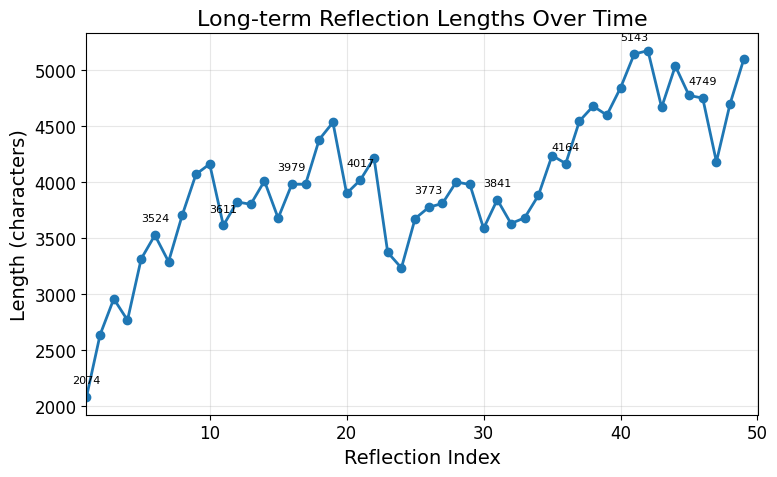

In [16]:
import matplotlib.pyplot as plt
from plotlib import color_scheme, font_scheme


# Create the plot
plt.figure(figsize=(8, 5))
plt.rcParams.update(font_scheme)

plt.plot(range(1, len(lengths) + 1), lengths, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('Reflection Index')
plt.ylabel('Length (characters)')
plt.title('Long-term Reflection Lengths Over Time')
plt.grid(True, alpha=0.3)
plt.xlim(1, 50)

# Add value labels for some points
for i, length in enumerate(lengths):
    if i % 5 == 0:  # Label every 5th point
        plt.annotate(f'{length}', (i+1, length), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()